<a href="https://colab.research.google.com/github/IndiraTejaswini/Pytorch_Neural_networks/blob/main/Pytorch_Workflow_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks and matplotlib
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.10.0+cpu'

In [ ]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

 Now we're going to move towards building a model that can learn the relationship between X (features) and y (labels).

In [ ]:
# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

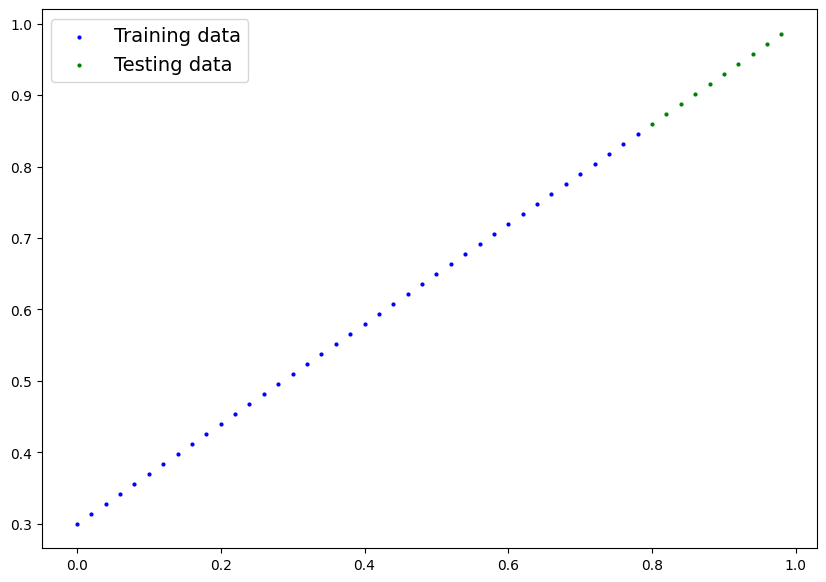

In [ ]:
plot_predictions();

def forward(self, ...):

 In PyTorch, every custom model inherits from nn.Module. When you define a forward method inside your class, PyTorch automatically uses it behind the scenes. You don't actually call model.forward(x) when running data; instead, you just call model(x), and PyTorch safely triggers this method for you.

x: This is the input data you pass into the model (such as your training features, images, or text embeddings).

 **Python Type Hinting Syntax**

The punctuation marks (:  and ->) are Python Type Hints. They don't change how the code runs, but they act as documentation to show what kind of data the function expects and returns.

x: torch.Tensor (Input Hint): This tells anyone reading the code (and code editors) that the input variable x is expected to be a PyTorch Tensor (the standard multi-dimensional array format used in PyTorch).

-> torch.Tensor (Output Hint): This arrow indicates the return type of the function. It means that whatever this method outputs after running its calculations will also be a PyTorch Tensor.

Basic building blocks of creating a PyTorch model by subclassing nn.Module. For objects that subclass nn.Module, the forward() method must be defined

In [ ]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

Now we've got these out of the way, let's create a model instance with the class we've made and check its parameters using .parameters().

In [ ]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

We can also get the state (what the model contains) of the model using .state_dict().



**What is a state_dict?**

In PyTorch, a state_dict (state dictionary) is simply a standard Python dictionary. It maps each layer or parameter name in your model to its corresponding numbers (tensors).

Because you ran torch.manual_seed(42) right before creating model_0, your model currently contains a specific set of random numbers. If you run model_0.state_dict(), PyTorch will return a dictionary that looks exactly like this:

In [ ]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

**Making predictions using torch.inference_mode()**

When you are training a model, PyTorch constantly works behind the scenes keeping track of every mathematical operation. It does this so it can calculate "gradients" (the direction the numbers need to move to get smarter) during backpropagation.

However, when you are just making predictions (also called inference), you don't need to train the model. You are just using it.

Putting your code inside with torch.inference_mode(): tells PyTorch: "Hey, I am only looking at predictions right now. Stop tracking gradients and turn off all the training machinery."

In [ ]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

In [ ]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


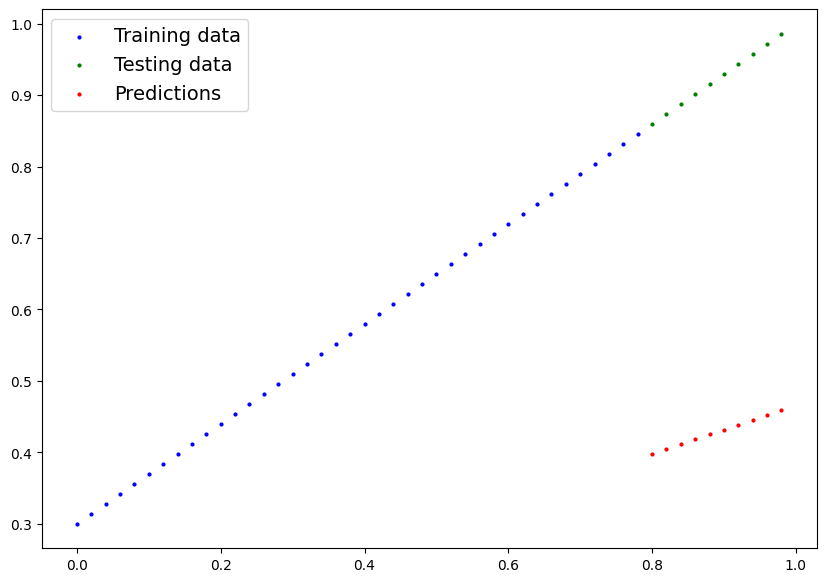

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

**Train model**

Right now our model is making predictions using random parameters to make calculations, it's basically guessing (randomly).

To fix that, we can update its internal parameters (I also refer to parameters as patterns), the weights and bias values we set randomly using nn.Parameter() and torch.randn() to be something that better represents the data.

For our problem, since we're predicting a number, let's use MAE (which is under torch.nn.L1Loss()) in PyTorch as our loss function.

**params** is the target model parameters you'd like to optimize (e.g. the weights and bias values we randomly set before).
**lr** is the learning rate you'd like the optimizer to update the parameters at, higher means the optimizer will try larger updates (these can sometimes be too large and the optimizer will fail to work), lower means the optimizer will try smaller updates (these can sometimes be too small and the optimizer will take too long to find the ideal values). The learning rate is considered a hyperparameter (because it's set by a machine learning engineer). Common starting values for the learning rate are 0.01, 0.001, 0.0001, however, these can also be adjusted over time (**this is called learning rate scheduling**).

In [ ]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), # parameters of target model to optimize
                            lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

**Creating an optimization loop in PyTorch**

Woohoo! Now we've got a loss function and an optimizer, it's now time to create a training loop (and testing loop).


Let's put all of the above together and train our model for 100 epochs (forward passes through the data) and we'll evaluate it every 10 epochs.



In [ ]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819 


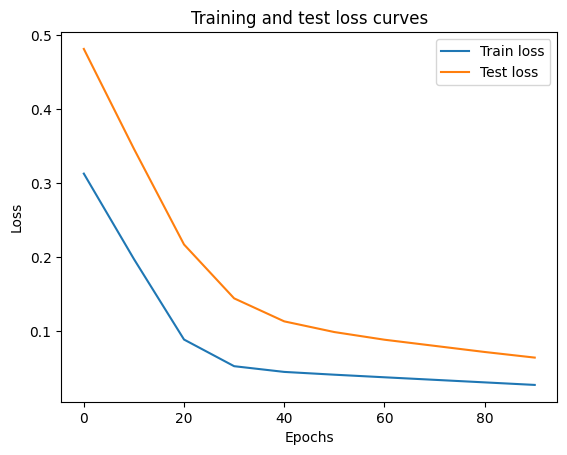

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [ ]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.5784]), 'bias': tensor([0.3513])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


You started with a model that knew absolutely nothing—it was just guessing random numbers ($0.3367$ and $0.1288$). But by setting up that training loop, you forced it to look at data, calculate its mistakes (loss), and adjust itself step-by-step using the optimizer.


1. **Your Fixed Target (The "Teacher's Answer Key")**


weight = 0.7

bias = 0.3

These values were used to generate your dataset (y = weight * X + bias). Your model was never allowed to look at these two variables during training. It only got to look at the resulting X and y data points.

2. **Your Model's Parameters (The "Student's Guesses")**


At Step 8 (Before Training): Inside your LinearRegressionModel class, you used torch.randn(1). Because you set a manual seed of 42, PyTorch initialized model_0 with these exact random starting numbers:

weights: 0.3367

bias: 0.1288

At Step 15 & 17 (After 100 Epochs of Training): Your training loop forced the model to practice. The optimizer nudged those starting numbers over and over again until they reached:

weights: 0.5784

bias: 0.3513


by using loss and optimizer we got close to our target so our model is trained well

**4. Making predictions with a trained PyTorch model (inference)**

In [ ]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
y_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

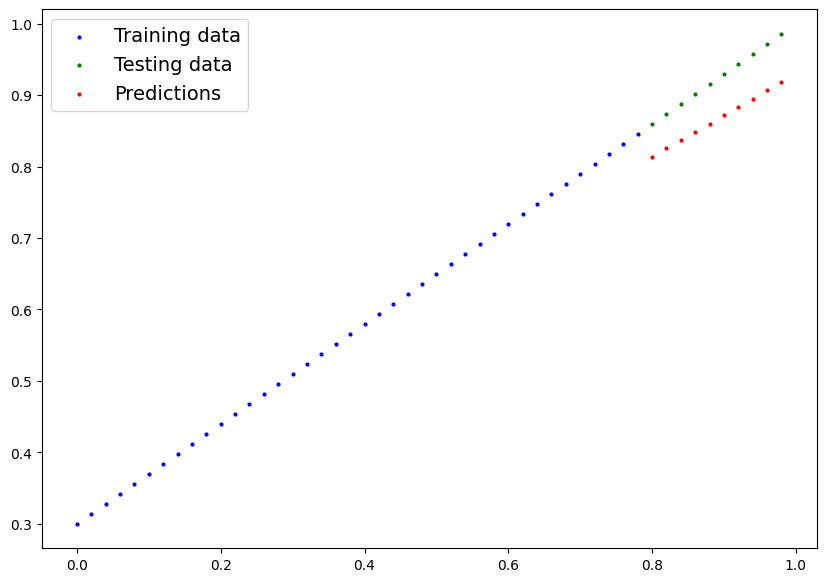

In [ ]:
plot_predictions(predictions=y_preds)

**5. Saving and loading a PyTorch model**

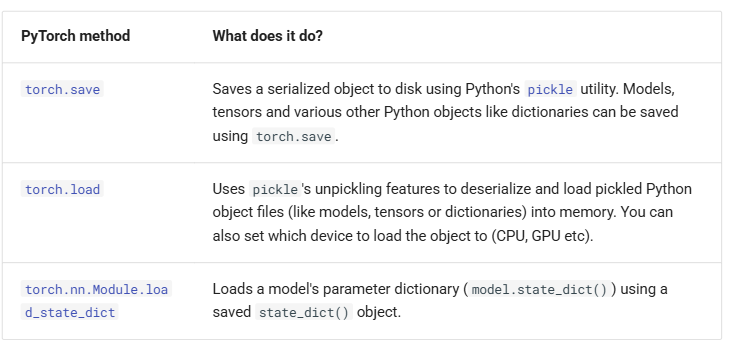

**Saving a PyTorch model's state_dict()**

The recommended way for saving and loading a model for inference (making predictions) is by saving and loading a model's state_dict().

Let's see how we can do that in a few steps:

We'll create a directory for saving models to called models using Python's pathlib module.
We'll create a file path to save the model to.
We'll call torch.save(obj, f) where obj is the target model's state_dict() and f is the filename of where to save the model.
Note: It's common convention for PyTorch saved models or objects to end with .pt or .pth, like saved_model_01.pth.

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
# Check the saved file path
!ls -l models/01_pytorch_workflow_model_0.pth

-rw-r--r-- 1 root root 2117 May 24 12:39 models/01_pytorch_workflow_model_0.pth


Now that your model has learned those improved weights (0.5784) and bias (0.3513), you are at a critical step: saving your progress. If you closed your Google Colab notebook right now without saving, the virtual machine would shut down, and your trained model would be deleted. You would have to re-run the training loop all over again next time.

Here is exactly what the author means and what is happening mechanically in this code block:

**Step-by-Step Breakdown of the Code**


Your notebook uses Python's built-in pathlib module to handle files cleanly, followed by PyTorch's saving function.

**Step 1: Create a folder named "models"**

from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

**What it means: **This creates a new folder named models inside your temporary Colab file directory.

**exist_ok=True** is a safety feature. It tells Python: "If the folder 'models' already exists, don't crash, just move on."

**Step 2: Define the file name and path**

MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

**What it means:** This combines your folder name and your desired file name together. The final target location becomes models/01_pytorch_workflow_model_0.pth.

**Why .pth?** As the text notes, ending your file name with .pt or .pth is simply the universal rule/convention that PyTorch developers use to signify a "PyTorch weights file".

**Step 3: Freeze the brain and save it**
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

**What it means:** This is the line that actually writes the data to your storage disk.

Remember, model_0.state_dict() is just a Python dictionary containing your hard-earned numbers: {'weights': tensor([0.5784]), 'bias': tensor([0.3513])}.

torch.save() takes that dictionary, converts it into a serialized file format, and writes it directly into the 01_pytorch_workflow_model_0.pth file.

**Why is this the "Recommended Way"?**


You might wonder: Why don't we just save the whole model object?

PyTorch allows you to save the entire model structural class, but it is highly discouraged because it binds the saved file to your exact directory paths and specific Python class definitions. If you tried to load it in a different project script later, it would easily break.

By saving only the state_dict(), you are saving the raw mathematical values. It creates a tiny, incredibly lightweight file (as your next notebook cell shows, it takes up only about 2117 bytes!).

Whenever you want to use this model in the future, you will just write a clean blueprint class, create a blank model, and inject these exact numbers right back into it.

Lets try this out





## **Loading a saved PyTorch model's state_dict()**

In [ ]:
# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegressionModel()

# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
# 1. Put the loaded model into evaluation mode
loaded_model_0.eval()

# 2. Use the inference mode context manager to make predictions
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test) # perform a forward pass on the test data with the loaded model

In [ ]:
# Compare previous model predictions with loaded model predictions (these should be the same)
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])